

https://github.com/earnanderieu2023-pixel/ML_fundamentals_2026.git


### Individual Assignment 1
**Estelle Arnander**

_Machine Learning Foundations - Data Preparation_

**Prof. Matteo Turilli**

3/3/2026

-----




_Given client and campaign information available at the time of contact, predict whether the client subscribes to a term deposit (i.e., a type of short-term investment)._

In [1]:
#load libraries

import pandas as pd
import numpy as np
from dataclasses import replace
import matplotlib.pyplot as plt
import seaborn as sns
from pyparsing import WordEnd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from statsmodels.stats.outliers_influence import variance_inflation_factor
from imblearn.over_sampling import SMOTE, ADASYN, RandomOverSampler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, RocCurveDisplay
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix


# **0. Task Ordering**



#### **1. Identifying the Prediction Target**
Before any data is loaded or explored, the prediction target must be identified and understood. If we do not know what we are trying to predict, we cannot make the right choices about feature selection, encoding, or evaluation metrics.

- **Allowed:** examining the dataset schema, understanding what each variable represents, identifying which column is the target
- **Not allowed:** Tranformations, quantifying predictive power of any feature
- **Leakage risk if violated:** If the target is misidentified or a feature that acts as a proxy for the target is accidentally included, like duration in this dataset, the model may learn patterns that are not present when making real predictions. This can make performance estimates look better than they actually are in real-world use.



#### **2. Data Loading and Exploration**
After defining the target, load the dataset and explore it to understand its structure, variable types, missing values, and class distribution. This step is only for diagnosis; you do not fit any statistics or apply transformations yet.

- **Allowed:** loading the full dataset, observing distributions, visualizing class balance, identifying missing values, examining feature types and ranges
- **Not allowed**: fitting statistics, analyzing how target and feature variables relate, and deciding on data transformations using holdout data
- **Leakage risk if violated:** If you calculate summary statistics or correlations with the target using the entire dataset before splitting, it can bias your preprocessing and feature selection toward the holdout set. These decisions should be made without looking at validation or test examples.

#### **3. Data Splitting**

The dataset is to be divided into training, validation, and test sets before you start any preprocessing. This is the most important step in the process because every following step must use only the training data, which is only possible if you split the data first.

- **Allowed**: the full raw dataset, stratification by target variable to preserve class proportions
- **Not allowed**: any transformation, fitting, or preprocessing before this point
- **Leakage risk if violated:** If you apply any preprocessing before splitting the data, such as scaling, encoding, imputation, or resampling, the fitted parameters will include information from the holdout examples. As Burkov explains in Section 3.6, Condition 1 is that "the split was applied to raw data before everything else." Breaking this rule is the most basic pipeline mistake because it makes all later evaluation metrics unreliable, even though the model seems to work fine and shows no obvious errors.

#### **4. Managing missing values**
Once the data is split, handle missing values using only the training set. If you calculate imputation statistics before splitting, information from the holdout sets could affect how missing values are filled.

- **Allowed:** imputation statistics computed on training set only, deterministic rules applied identically across all sets
- **Not allowed**: computing mode, mean, or any imputation statistic on the full dataset or on validation and test sets
- **Leakage risk if violated:** As Burkov explains in Section 3.7.2, calculating imputation statistics using the full dataset can mix information from the holdout set into the training data. In this assignment, "unknown" was kept as its own category using a simple rule that does not require fitting, so the order of steps does not matter here. However, if you use any fitted imputation statistic, you must apply it only after splitting the data.

#### **5. Encoding categorical variables**
Convert categorical variables to numbers using encoders that are fitted only on the training set. This step comes after splitting because the encoder should only learn from the training data.

- **Allowed:** OrdinalEncoder and OneHotEncoder fitted on training set only, then applied to validation and test via .transform()
- **Not allowed**: fitting encoders on the full dataset or on validation and test sets
- **Leakage risk if violated:** fitting encoders on the full dataset allows the vocabulary to learn category distributions from holdout examples. Concretely, if a rare category appears only in the test set, fitting on the full dataset would include it in the encoder vocabulary — the model would never encounter it during training but the encoder would have been informed by it. The handle_unknown='ignore' parameter ensures unseen categories in validation and test are handled gracefully without leakage.

#### **6. Feature scaling**
Standardize numerical features using a scaler fitted only on the training set. Scaling comes after encoding since the scaler works on the complete set of numerical features.

- **Allowed:** StandardScaler fitted on training set only, mean and standard deviation computed from training distribution, `.transform()` applied to validation and test
- **Not allowed**: fitting scaler on full dataset, computing scaling parameters from validation or test examples
- **Leakage risk if violated:** If you fit StandardScaler on the entire dataset, the mean and standard deviation include information from the holdout set in every scaled training feature. The model will not show obvious problems, and the metrics may look fine, but the evaluation will be too optimistic. This is the most common preprocessing leakage error in practice because there is no clear warning sign.

#### **7. Feature selection**
Identify and remove multicollinear features using correlation and VIF statistics, calculated only on the training set. Do this after scaling, since VIF scores depend on the feature scale.

- **Allowed:** correlation coefficients and VIF scores computed on training set only, removal of multicollinear features based on training distribution
- **Not allowed**: computing multicollinearity statistics on the full dataset or informed by validation and test feature relationships
- **Leakage risk if violated:** VIF and correlation are statistics based on feature values. If you calculate them using the full dataset, the relationships in the test set can affect which features you keep. This means your feature set may fit the holdout data instead of capturing patterns that generalize well. For Logistic Regression, it is important to check multicollinearity only on the training data. The model expects stable linear relationships between features and log-odds, so checking this on data the model never sees during training can lead to unreliable coefficient estimates.

#### **8. Class imbalance handling**
Apply resampling to the training set only, after all other preprocessing steps are finished. Resampling should be last because it works on the fully encoded and scaled data. Doing it earlier could change the transformation parameters.

- **Allowed:** resampling applied to training set only, after all preprocessing steps are complete
- **Not allowed**: resampling before splitting, before encoding, or before scaling, resampling validation or test sets
- **Leakage risk if violated:** If you apply resampling before splitting your data, you end up with duplicate minority class examples in both the training and holdout sets. This means the model is tested on data it has already seen, which leads to inflated recall and F1 scores that do not show real generalization. If you resample before encoding, you just duplicate raw string values, which does not help. Doing it before scaling can also distort the scaler’s mean and standard deviation, since the minority class feature values are overrepresented in the statistics.

#### **9. Model training and evaluation**
Train the model on the preprocessed and resampled training set, and evaluate it on the validation set. Keep the test set untouched until the very end for a final, unbiased evaluation.

- **Allowed:** fully preprocessed and resampled training set for fitting, validation set for evaluation and pipeline configuration decisions, comparison of model variants
- **Not allowed**: any use of test set during training or model selection, refitting any preprocessing parameter on validation or test data, using validation metrics to directly optimize model weights
- **Leakage risk if violated:** Using the test set during model selection, even just for comparing models, leads to evaluation leakage. The test set stops being an unbiased measure of generalization as soon as it influences any decision in the pipeline. As Burkov explains in Section 5.1.5, the test set should only be used for the final reporting of the best model found on the validation set. In this assignment, the test set stays completely sealed. Its integrity was checked by making sure there was no index overlap and that the class distribution was preserved. It is saved for one final, unbiased evaluation.

### **0.1 Example of Incorrect Ordering: Scaling Before Splitting**

One of the most common and serious mistakes is fitting the StandardScaler before splitting the data into train, validation, and test sets. The scaler calculates the mean and sd using the entire dataset, including examples that should stay hidden in the holdout sets.


The model may seem to work fine. Accuracy, precision, and recall all look good. But every metric is actually too optimistic because the preprocessing used information from the holdout data. Once the model is in production and only training statistics are available, the scaling parameters will be different and performance will drop. The evaluation results gave a false sense of confidence.


This is exactly why preprocessing leakage is such a dangerous pipeline mistake. There are no errors, warnings, or clear signs that something is wrong. The pipeline looks correct, the metrics seem reliable, and the issue only shows up after deployment. As Burkov explains in Section 3.7.2, this kind of leakage is less severe than target leakage but still needs to be avoided. On datasets where the training and holdout sets are more different than in this example, the performance gap between a leaked and a clean pipeline would be much larger.




# **1. Identifying the Prediction Target**

The target variable for this assignment is **y**. It is a binary variable that shows whether the client has subscribed to a term deposit, with possible answers being "yes" or "no."

## **1.1 Why `y` represents the appropriate prediction objective**

The goal of this campaign is to find out, before or during a call, which clients are most likely to subscribe to a term deposit. This helps the bank focus on clients with a higher chance of signing up, which lowers campaign costs and improves conversion rates by reaching the right customer groups.

**It satisfies every criterion for a valid prediction target:**

- **Causal role:** This is the effect we want to predict, not the cause.
- **Tmporality**: We observe this after the campaign contact, so it works as a valid label for supervised learning
- **Business-relevance:** Predicting this allows us to make decisions before making a call.
- **Measurability:** This is a clear, unambiguous binary outcome with no special or missing values. According to Lecture 1, this is a **binary classification problem**: we map a feature vector $\mathbf{x}$ (client and campaign attributes available at the time of contact) to a label $y \in \{\text{no}, \text{yes}\}$.


## **1.2 Variables that could superficially appear to be valid targets (not are not)**

Some variables in the dataset may look like good prediction targets at first, but they are not suitable for this task.

#### **1. `duration`**
Records how long the previous phone call lasted (in seconds).

- A call that ends quickly likely means the client declined, while a long call often leads to a subscription.
- One might be tempted to treat duration as a proxy for y.

**Why it's not:**
- Duration is not known before the call is made.
- At prediction time, when we want to decide whether to call a client at all, this value simply does not yet exist.
- Using duration as a target would lead to target leakage bc. it holds information that is only available after the outcome is made.

#### **2. `poutcome`**
Records whether a prior campaign resulted in a success, failure, or nonexistent outcome (meaning no prior contact).

- Might seem like a good target since it reflects campaign success.

**Why it's not:**
- But poutcome actually describes a past event from a different, earlier campaign, not the current one.
- Since this is historical information already available when making predictions, using it as the target would mean predicting something we already know, instead of future subscription behavior.
- That would make the task too easy and not useful for business.
- Also, poutcome has three categories, which does not fit the bank’s goal of a binary classification.


## **1.1.3 Summary**

y is the only variable that meets all three requirements for a valid prediction target.
- It stands for the business outcome we want to predict
- Is not available at prediction time
- Does not use information from after the prediction point.
- The other columns, such as duration, poutcome, campaign, and pdays, fail to meet at least one of these rules because of problems like data leakage, timing, or not matching the business goal.


# **2. Data Loading and Exploration**

This is the next logical step because everything else depends on actually understanding what's in the data. You can't make informed decisions about splitting, encoding, missing values, or scaling without first inspecting the dataset's structure, distributions etc.

## **2.1 Load dataset into Pandas Dataframe**

In [2]:
data = pd.read_csv('bank-additional.csv',sep = ';')

display(data.head())

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,...,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,...,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,...,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no


(4119, 21)
<class 'pandas.DataFrame'>
RangeIndex: 4119 entries, 0 to 4118
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             4119 non-null   int64  
 1   job             4119 non-null   str    
 2   marital         4119 non-null   str    
 3   education       4119 non-null   str    
 4   default         4119 non-null   str    
 5   housing         4119 non-null   str    
 6   loan            4119 non-null   str    
 7   contact         4119 non-null   str    
 8   month           4119 non-null   str    
 9   day_of_week     4119 non-null   str    
 10  duration        4119 non-null   int64  
 11  campaign        4119 non-null   int64  
 12  pdays           4119 non-null   int64  
 13  previous        4119 non-null   int64  
 14  poutcome        4119 non-null   str    
 15  emp.var.rate    4119 non-null   float64
 16  cons.price.idx  4119 non-null   float64
 17  cons.conf.idx   4119 non-null   f

## **2.1 Structure of the dataset**

In [4]:
print(data.shape)

data.info()

print(f"\nNumber of Numerical variables: {len(data.select_dtypes(include = ["int64", "float64"]).columns.tolist())}")
print(f"Number of Categorical variables: {len(data.select_dtypes(include = ["str"]).columns.tolist())}")

(4119, 21)
<class 'pandas.DataFrame'>
RangeIndex: 4119 entries, 0 to 4118
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             4119 non-null   int64  
 1   job             4119 non-null   str    
 2   marital         4119 non-null   str    
 3   education       4119 non-null   str    
 4   default         4119 non-null   str    
 5   housing         4119 non-null   str    
 6   loan            4119 non-null   str    
 7   contact         4119 non-null   str    
 8   month           4119 non-null   str    
 9   day_of_week     4119 non-null   str    
 10  duration        4119 non-null   int64  
 11  campaign        4119 non-null   int64  
 12  pdays           4119 non-null   int64  
 13  previous        4119 non-null   int64  
 14  poutcome        4119 non-null   str    
 15  emp.var.rate    4119 non-null   float64
 16  cons.price.idx  4119 non-null   float64
 17  cons.conf.idx   4119 non-null   f

The data contains 4,119 observations, 20 input features and 1 target variable.
- 10 numerical
- 9 catecorgical variables.
- Three types of variables (integer (numerical), float (numerical) and string categorical)) which can be seen from the code output above.

### **2.1.1 Summary statistics of numerical variables**



In [5]:
data.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000
mean,40.113620,256.788055,2.537266,960.422190,0.190337,0.084972,93.579704,-40.499102,3.621356,5166.481695
std,10.313362,254.703736,2.568159,191.922786,0.541788,1.563114,0.579349,4.594578,1.733591,73.667904
min,18.000000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.635000,4963.600000
25%,32.000000,103.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.334000,5099.100000
50%,38.000000,181.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.000000,317.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,88.000000,3643.000000,35.000000,999.000000,6.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


### **2.1.2 Variables and their uniqe values**

In [ ]:
for col in data.columns:
    print(f'\n{col}: {data[col].unique()}\n')


- The variables job, marital, education, default, loan, has a category called "unknown".
- poutcome has a value of "nonexistent", this probably means that the client was not included in the previous campaign.
- pdays has a value of 999, a sentinal value probably.

This is quantified below.

##  **2.2 Missing Values**



In [109]:
print(f"Explicit missing values: {data.isna().sum()}") if data.isna().sum().sum() > 0 else print("No explicit missing values")

unknown_count = data.replace('unknown', pd.NA).isna().sum()
print(f"\nImplicit missing values:\n{unknown_count[unknown_count > 0]}")

No explicit missing values

Implicit missing values:
job           39
marital       11
education    167
default      803
housing      105
loan         105
dtype: int64


There are no explicit missing values (NaN) in the raw dataset. Still, some categorical columns use the string "unknown" to show that information was unavailable, not recorded, or intentionally withheld by the client.

Before deciding how to handle these entries, it is important to ask if missing information has meaning. In real situations, when a client does not share their job type or credit default status, it might show a pattern that helps predict the outcome. If we automatically fill in or remove these entries, we could lose that useful signal, which is a big assumption to make without good reason.

So, it is important to tell apart two types of missing data.
- **Explicit missingness**, like NaN, is usually handled with statistical imputation.
- **Implicit or structural missingness**, like the "unknown" category, might show patterns in the data and should sometimes be kept as its own category instead of being filled in.

Later, during preprocessing, we will decide for each variable whether to fill in, drop, or keep these values as a separate category, depending on how much data is missing and how it relates to the target.

The variable with the most missing data is default (19.5%), followed by education (4.1%), housing and loan (2.5%), job (0.9%), and marital (0.3%).

## **2.3 Distribution of the Target Variable**







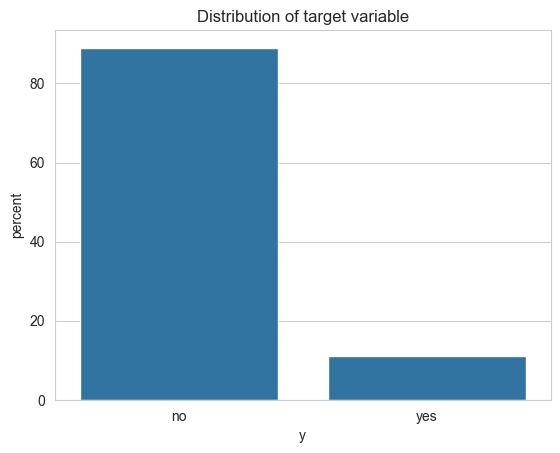

%faliure (no): 89.05%
%sucess (yes): 10.95%


In [107]:
sns.countplot(x='y', data=data, stat='percent')
plt.title('Distribution of target variable')
plt.show()

no,yes = data['y'].value_counts(normalize=True).mul(100).round(2)

print(f'%faliure (no): {no}%\n%sucess (yes): {yes}%')

The target variable is clearly imbalanced. About 89% of clients did not subscribe ('no'), while only 11% did ('yes'). Because of this, accuracy is not a reliable metric. A model that always predicts 'no' would still get 89% accuracy but would not provide any real insights. In this case, recall and F1-score are better ways to measure performance.

We will deal with the class imbalace in later stages of this notebook (propably with oversampling or similar)

## **2.4 Vizualizing numerical & Categorcial Variables**



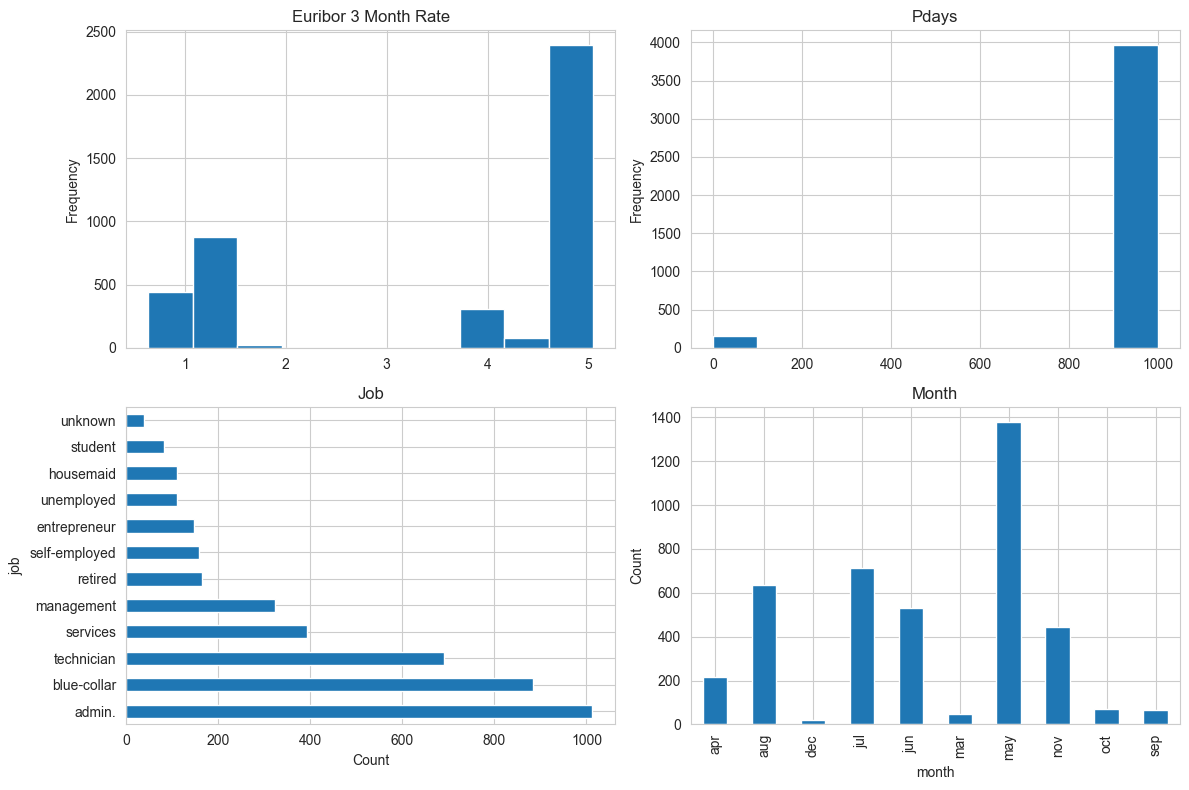

In [108]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Numerical
data['euribor3m'].plot(kind='hist', ax=axes[0, 0], title='Euribor 3 Month Rate')
data['pdays'].plot(kind='hist', ax=axes[0, 1], title='Pdays')

# Categorical
data['job'].value_counts().plot(kind='barh', ax=axes[1, 0], title='Job',xlabel = "Count")

data['month'].value_counts().sort_index().plot(kind='bar', ax=axes[1, 1], title='Month', ylabel='Count')

plt.tight_layout()
plt.show()

**Euribor 3 Month Rate:** The data shows two main clusters, with most values around 1 to 1.5 and 4.5 to 5. This pattern suggests the data covers two separate economic periods with different interest rates.

**Pdays:** The value 999 appears most often, showing that most clients were not contacted in a previous campaign. This confirms that 999 is used as a marker, not an actual measurement.

**Job:** The most common job types are admin, blue-collar, and technician. Housemaid, student, and unknown are much less frequent.

**Month:** May dominates contact activity by a large margin, followed by July and August. Notably the months are not in chronological order, this should be fixed for clarity. March, October and September saw very few contacts, suggesting the campaign was not active uniformly throughout the year.

## **2.5 Variables that require special consideration**

**`duration`**  should not be included in any realistic model. It shows the length of the phone call, but this information is only available after the call ends, when the outcome is already known. Using it would cause target leakage, as explained in Task 1.

**`pdays`** should not be treated as a regular numerical variable. The histogram shows that about 97% of the values are 999, which means the client was never previously contacted. The other values show the actual number of days since the last contact. Because this column mixes two different types of information, it needs special handling before modeling. For example, 999 could be converted into a binary indicator for "never contacted."


# **3. Data Splitting**



## **3.1 Why Splitting the Data should occur now?**

You should split your data right after loading it and identifying the target variable. Do this before any preprocessing steps that learn from the data, such as imputation, scaling, encoding, resampling, or feature selection.

- If you split the data later, any transformation fitted on the whole dataset will have already used the validation and test data.
- For example, if you fit a StandardScaler on the entire dataset, it will calculate the mean and standard deviation using test samples. This means the model gets information about the test set during training.
- The same problem happens with imputation. If you calculate the mean of a column using all 4,119 rows, the result includes test set values, which would not be available when the model is deployed. This situation is called data leakage.
- The model is then evaluated in a way that does not match real-world conditions, leading to performance estimates that are too optimistic and do not show how well the model will actually generalize.


## **3.2 Performing Stratified Splitting.**

First, we need to separate the dataset from the outcome variable. Here’s how it looks:

The dataset is divided into the following parts:
- X: the feature matrix with all predictor variables.
- y: the target variable that shows the subscription outcome.

Given the strong class imbalance (~11% "yes"), a random split risks producing holdout sets with a different class distribution than the training set. If the validation or test set ends up with fewer "yes" samples than expected, evaluation metrics like recall and F1 become unreliable. Stratification guarantees that each split preserves the original class distribution (approximetly) ensuring that performance estimates on the validation and test sets are representative of the true data distribution.

- Training set: 60%
- Test set: 20%
- Validation: 20%




In [110]:
X = data.drop(columns='y')
y = data['y']

# First split: 60% train, 40% temp
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, stratify=y, random_state=42)

# Second split: temp into 50/50 validation and test (15% each of total)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

print(f"Shape:\nTrain:{X_train.shape}\nValidation: {X_val.shape}\nTest: {X_test.shape}")

Shape:
Train:(2471, 20)
Validation: (824, 20)
Test: (824, 20)


## **3.3 Split proportions motivation**
I chose a 60/20/20 split because the dataset has only 4,119 samples, with just 11% in the minority class. Each holdout set needs enough "yes" samples for reliable evaluation. With 20% splits, both validation and test sets have about 90 minority class samples, which is close to Burkov's recommended 100. An 80/10/10 split would give only about 45 "yes" samples per holdout set, which is too few. A 70/15/15 split gives around 68, which is better but still not enough. Since Logistic Regression does not need a huge amount of training data, using 20% less for training is worth it for more reliable evaluation. The code below shows this choice.

In [112]:
for name, pct in {'80/10/10': 0.1, '70/15/15': 0.15, '60/20/20': 0.2}.items():
    minority = int(len(y) * pct * 0.1095)
    print(f'{name}: {minority} minority class samples per holdout set')

80/10/10: 45 minority class samples per holdout set
70/15/15: 67 minority class samples per holdout set
60/20/20: 90 minority class samples per holdout set


## **3.4 Verify Stratification**

In [111]:
print(f'Original: \n{round(y.value_counts(normalize=True),5)}')
print(f'\nTrain:\n {round(y_train.value_counts(normalize=True),5)}')
print(f'\nValidation:\n {round(y_val.value_counts(normalize=True),5)}')
print(f'\nTest: \n{round(y_test.value_counts(normalize=True),5)}')

Original: 
y
no     0.89051
yes    0.10949
Name: proportion, dtype: float64

Train:
 y
no     0.89033
yes    0.10967
Name: proportion, dtype: float64

Validation:
 y
no     0.89078
yes    0.10922
Name: proportion, dtype: float64

Test: 
y
no     0.89078
yes    0.10922
Name: proportion, dtype: float64


**The output shows that stratification worked as intended. All three sets keep the original 10.9% minority class proportion, which is exactly what we want.**


# **4. Managing Missing Values**


## **4.1 Missing values & Sentinal numerical values**

In Task 2, I found that the dataset does not have explicit missing values, but it does include some implicit ones marked as "unknown" and a sentinel value in **`pdays`**. Now that the data has been split, we are checking for missing values only in the training set. This way, we make sure that no information from the validation or test sets affects our preprocessing choices.

**I found three types of problematic values:**
- explicit missing values (NaN)
- implicit missing values ("unknown")
- sentinel numerical values.

In [113]:
#explicit missing values
print(f"Explicit missing values: {X_train.isna().sum()}") if X_train.isna().sum().sum() > 0 else print("No explicit missing values")

#implicit missing values
unknown_count2 = X_train.replace('unknown', pd.NA).isna().sum()
print(f"\nImplicit missing values:\n{unknown_count2[unknown_count2 > 0]}")

#sentinal values
print(f'\npdays = 999: \n{(X_train["pdays"] == 999).sum()} samples ({(X_train["pdays"] == 999).mean()*100:.1f}%)')


No explicit missing values

Implicit missing values:
job           20
marital        7
education    104
default      492
housing       55
loan          55
dtype: int64

pdays = 999: 
2368 samples (95.8%)


The counts match what we saw in Task 2, but this time they are limited to the training set.
- `default` is still the most affected variable at about 20%, followed by `education`, `housing`, `loan`, `job`, and `marital`.
- The pdays sentinel supports what the histogram showed: 95.8% of clients were never contacted before. This means the column does not work as a regular numerical variable, but instead shows two clear groups: clients who were contacted before (4.2%) and those who were not (95.8%). Using 999 as a real number and including it with actual day counts would not make sense. So, pdays will be changed to a binary variable: 0 for never contacted and 1 for previously contacted. This will give the model a clear signal.

## **4.2 Extent of missingness**
The table below quantifies the extent of missingness

In [114]:
unknown_count2['pdays'] = (X_train['pdays'] == 999).sum()
pct = (unknown_count2 / len(X_train) * 100).round(2)
pd.DataFrame({'count': unknown_count2[unknown_count2 > 0], '%': pct[pct > 0]})

,count,%
job,20,0.81
marital,7,0.28
education,104,4.21
default,492,19.91
housing,55,2.23
loan,55,2.23
pdays,2368,95.83


## **4.3 Handling missing values**

If a categorical variable includes "unknown" as a value, it will be kept as its own category instead of being filled in or removed.

There are two main reasons for this choice.
1. Dropping observations would unnecessarily reduce an already small dataset.
2. More importantly, the reason a client did not share information, especially financial details like default, could actually help predict subscription behavior. If we fill in the most common value, we might lose this useful signal. As Burkov points out, we can't know the best way to fill in missing data before modeling, so keeping "unknown" as its own category is the safest and most transparent option.

For pdays, the 999 sentinel will be replaced by creating a new binary variable **`previously_contacted`** (1 if pdays ≠ 999, 0 otherwise), This preserves the structural meaning of the variable without allowing the model to misinterpret 999 as a genuine numerical magnitude.




In [115]:
# Retain 'unknown' as a separate category - no action needed as it is already a string category

# Create binary indicator for pdays
X_train['previously_contacted'] = (X_train['pdays'] != 999).astype(int)
X_val['previously_contacted'] = (X_val['pdays'] != 999).astype(int)
X_test['previously_contacted'] = (X_test['pdays'] != 999).astype(int)

X_train['pdays'] = X_train['pdays'].replace(999, 0)
X_val['pdays'] = X_val['pdays'].replace(999, 0)
X_test['pdays'] = X_test['pdays'].replace(999, 0)

## **4.4 Operations that needs to be fitted using the training set only (and why)**

When you use a transformation that estimates something about the data distribution, fit it only on the training set. Then, apply it to the validation and test sets using .transform(). If you calculate these statistics on the whole dataset, the holdout examples can affect the transformation, which leads to preprocessing leakage, as Burkov explains in Section 3.7.2.

In this assignment two types of decisions were made.
1. Deterministic rules such as keeping "unknown" as its own category and using the two-part pdays transformation (replacing 999 with 0 and creating previously_contacted) do not require fitting. These rules are applied the same way to all three sets, so there is no risk of data leakage.
2. if mode imputation were used for any variable, the mode should be calculated only on the training set. This difference is important because deterministic rules address clear inconsistencies regardless of the data distribution, while fitted statistics estimate properties of the data and must not use information from the holdout set.




# **5. Encoding Categorical Values**


## **5.1. Identification and classification (nomial vs. ordinal) of categorical variables**

In [116]:
print("Categorical variables:")
print(X_train.select_dtypes(include='str').columns.tolist())

Categorical variables:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']


**Ordinal variables (categories with a meaningful order):**
- The only ordinal variable here is **`education`**.
- This variable follows a clear order: basic.4y, basic.6y, basic.9y, high.school, professional.course, and university.degree.
- This order shows increasing levels of education, so it should be kept when encoding. Use ordinal encoding instead of one-hot encoding.

**Nominal variables (no intrinsic order):**
All of these are nominal variables, which means there is no meaningful ranking among their categories.
- **`job`**
- **`marital`**
- **`contact`**
- **`poutcome`**
- **`default`**
- **`housing`**
- **`loan`**
**`month`** and **`day_of_week`** are worth mentioning separately. Even though they have a natural order in time, here they show campaign timing patterns, not a continuous progression. Also they have cyclical properties. For example, December and January are next to each other in time, just like Monday and Friday are close within a week. Using sine-cosine transformation for cyclical encoding would keep this circular relationship. However, since these variables reflect campaign timing based on operational choices instead of a natural cycle, we decided to use one-hot encoding. In this case, the specific campaign activity patterns for each month or day matter more than their cyclical structure.

## **5.2 Applying an appropriate encoding strategy for each categorical variable.**
- #### For ordinal variables, we use `OrdinalEncoder` with an explicit category order
- #### For nominal variables, we use `OneHotEncoder`

Logistic Regression assumes a linear relationship between the input features and the log-odds of the target, which affects how we should encode data.
- **One-hot encoding** works well for nominal variables because it does not assume any relationship between categories.
- Each category gets its own coefficient, so the model can learn their effects separately.
- If we assign a numeric order to nominal categories like job or marital status, the model would treat the difference between any two categories as equal.
- This is not accurate and could distort the model’s decision boundary.

For **`education`**, ordinal encoding makes sense because the order of education levels is meaningful. It is reasonable to assume that higher education might be linked to greater financial awareness and higher subscription rates. Using ordinal encoding also keeps the number of features lower than one-hot encoding, while still letting Logistic Regression use the order through a single coefficient.


In [117]:
cat_cols = X_train.select_dtypes(include='str').columns.tolist()

ord_columns = ['education']
nom_columns = [column for column in cat_cols if column not in ord_columns]

edu_order = ['unknown', 'illiterate', 'basic.4y', 'basic.6y', 'basic.9y',
             'high.school', 'professional.course', 'university.degree']

oe = OrdinalEncoder(categories=[edu_order])
ohe = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')

# Fit on training set only
X_train_ord_enc = oe.fit_transform(X_train[ord_columns])
X_train_nom_enc = ohe.fit_transform(X_train[nom_columns])

# Apply to validation and test
X_val_ord_enc = oe.transform(X_val[ord_columns])
X_test_ord_enc = oe.transform(X_test[ord_columns])

X_val_nom_enc = ohe.transform(X_val[nom_columns])
X_test_nom_enc = ohe.transform(X_test[nom_columns])

print(f'Education encoded into {X_train_ord_enc.shape[1]} ordinal column')
print(f'Nominal variables expanded into {X_train_nom_enc.shape[1]} binary columns after one-hot encoding')

Education encoded into 1 ordinal column
Nominal variables expanded into 36 binary columns after one-hot encoding


When you drop a reference category, its effect is included in the intercept, so all other coefficients are measured relative to that group instead of being absolute values. This makes interpretation a bit more complex because each coefficient should be understood as 'compared to the reference category.' Still, for this assignment, where the main goal is to set up the pipeline correctly rather than focus on interpreting each coefficient, this approach works well.

##  **5.3 Why both encoders are fitted on the training set only.**

The `OrdinalEncoder` learns the mapping between category strings and integers, and the `OneHotEncoder` learns which categories exist. Fitting on the full dataset would expose the encoders to category distributions from the validation and test sets, constituting leakage.

## **5.4 Analysis of changes due to encoding**

In [118]:
numerical_cols = X_train.select_dtypes(exclude='str').columns.tolist()
total_after = len(numerical_cols) + X_train_ord_enc.shape[1] + X_train_nom_enc.shape[1]

print(f'Features before encoding: {X_train.shape[1]}')
print(f'Features after encoding:  {total_after}')
print(f'  - Numerical (unchanged): {len(numerical_cols)}')
print(f'  - Ordinal (education):   {X_train_ord_enc.shape[1]}')
print(f'  - One-hot encoded:       {X_train_nom_enc.shape[1]}')

Features before encoding: 21
Features after encoding:  48
  - Numerical (unchanged): 11
  - Ordinal (education):   1
  - One-hot encoded:       36


#### **Dimensionality**

Encoding raised the number of features compared to the original set. One-hot encoding mainly causes this increase because it turns each nominal variable into several binary columns. Using drop='first' helps a bit by removing one reference category per variable to prevent multicollinearity.

#### **Interpretability**

Each one-hot coefficient shows the effect of being in a certain category compared to the dropped reference group, with everything else held constant. The ordinal coefficient for education shows how the log-odds change when moving up one level in education. Both types are clear to interpret, but it is important to remember which reference categories were dropped.

#### **Decision boundaries**

A linear model cannot handle categorical variables unless they are encoded. With one-hot encoding, Logistic Regression can give each category its own weight, so it learns how each category shifts the decision boundary. Ordinal encoding lets the model capture a steady relationship between education level and subscription chance, which makes sense because education has a natural order.


# **6. Feature Scaling**



## **6.1. Numerical variables that require scaling.**


In [119]:
numerical_cols = X_train.select_dtypes(exclude='str').columns.tolist()

print(numerical_cols)
print(f'\nSummary statistics:')
X_train[numerical_cols].describe().round(2)

['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'previously_contacted']

Summary statistics:


,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,previously_contacted
count,2471.00,2471.00,2471.00,2471.00,2471.00,2471.00,2471.00,2471.00,2471.00,2471.00,2471.00
mean,40.12,258.02,2.57,0.24,0.20,0.06,93.57,-40.43,3.60,5165.10,0.04
std,10.32,266.41,2.68,1.41,0.57,1.57,0.59,4.66,1.74,74.03,0.20
min,18.00,0.00,1.00,0.00,0.00,-3.40,92.20,-50.80,0.64,4963.60,0.00
25%,32.00,102.00,1.00,0.00,0.00,-1.80,93.08,-42.70,1.33,5099.10,0.00
50%,38.00,181.00,2.00,0.00,0.00,1.10,93.75,-41.80,4.86,5191.00,0.00
75%,47.00,314.00,3.00,0.00,0.00,1.40,93.99,-36.40,4.96,5228.10,0.00
max,86.00,3643.00,35.00,19.00,6.00,1.40,94.77,-26.90,5.04,5228.10,1.00


We are keeping **`duration`** for benchmarking, as mentioned in Task 1.
- We will leave it out of the realistic model when training Logistic Regression.
- We will train two models: one with duration for benchmarking, and one without for a more realistic scenario.

Based on the summary statistics, all numerical variables except **`previously_contacted`** need to be scaled.
- The ranges are very different. For example, **`nr.employed`** goes from 4963 to 5228, **`duration`** from 0 to 3643, and **`emp.var.rate`** from -3.4 to 1.4.
- When features have very different scales, Logistic Regression's gradient-based optimization updates weights unevenly. Features with large ranges can dominate the gradient steps, while those with small ranges may be ignored.
- We do not scale **`previously_contacted`** because it is a binary indicator (0/1) created from the pdays sentinel. Scaling would distort its meaning, since it is a category, not a continuous value.
- The variables that need scaling are: **`age`**, **`campaign`**, **`previous`**, **`emp.var.rate`**, **`cons.price.idx`**, **`cons.conf.idx`**, **`euribor3m`**, and **`nr.employed`**.

## **6.2 Choice of Scaling Method**

StandardScaler was selected instead of MinMaxScaler for three main reasons, all based on how Logistic Regression works mathematically.

1. **Logistic Regression minimizes log-loss using gradient descent.** If features are not scaled, the loss surface becomes stretched out, with some directions having steep gradients and others being flat. This makes the optimizer move inefficiently. Standardizing the features makes the loss surface more round, so gradient descent works faster and more relia2.
2. **Campaign and duration are right-skewed and have outliers.** MinMaxScaler puts all values between 0 and 1, but it is very sensitive to outliers. Just one extreme value can squeeze the rest of the data into a small range, which distorts the feature. StandardScaler is more robust because it uses standard deviation instead of the full range.range.

3. **Logistic Regression applies L2 regularization by default**, penalizing the sum of squared coefficients. If features are unscaled, features with small ranges produce artificially large coefficients just to compensate for their scale, and regularization penalizes them disproportionately. Standardization ensures the penalty is applied fairly and that the hyperparameter C has a consistent effect across all features.

## **6.3 Scaling numerical variables**



In [120]:
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_val_scaled = X_val.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_val_scaled[numerical_cols] = scaler.transform(X_val[numerical_cols])
X_test_scaled[numerical_cols] = scaler.transform(X_test[numerical_cols])

print("\n--- Mean and Standard Deviation of Standardized Data ---")
print("Means:\n", X_train_scaled[numerical_cols].mean().round(5))
print("\nStandard Deviations:\n", X_train_scaled[numerical_cols].std().round(5))


--- Mean and Standard Deviation of Standardized Data ---
Means:
 age                    -0.0
duration                0.0
campaign               -0.0
pdays                   0.0
previous               -0.0
emp.var.rate            0.0
cons.price.idx         -0.0
cons.conf.idx           0.0
euribor3m              -0.0
nr.employed             0.0
previously_contacted    0.0
dtype: float64

Standard Deviations:
 age                     1.0002
duration                1.0002
campaign                1.0002
pdays                   1.0002
previous                1.0002
emp.var.rate            1.0002
cons.price.idx          1.0002
cons.conf.idx           1.0002
euribor3m               1.0002
nr.employed             1.0002
previously_contacted    1.0002
dtype: float64


The mean of zero and standeviations of 1 indicate that the scaling woked as it should.

## **6.4 Transformations to be fitted soley on the training set (and why)**



You should fit the scaler only on the training set using fit_transform. Then, use the learned mean and standard deviation to transform the validation and test sets.

If we fitted the scaler on the full dataset, the mean and standard deviation would be computed using values from the validation and test sets. This means the training data would be scaled using statistics that were partially determined by held-out data — the model would indirectly have access to information it should never see during training. This is leakage, and it would produce overly optimistic evaluation results that do not reflect true generalization performance.

The same rule applies to any transformation that calculates statistics from the data. For example, you should fit OrdinalEncoder, OneHotEncoder, and StandardScaler only on the training set. Fixed transformations, like the pdays binary indicator, do not need fitting and can be used the same way on all three sets.

## **6.5 How feature scaling effects...**





#### **1. Gradient-based optimization**

Logistic Regression uses gradient descent to minimize log-loss. If features have very different scales, the loss surface stretches out. Gradients are steep for features with small scales and shallow for those with large scales. This makes the optimizer zigzag instead of moving straight to the minimum, which slows down training. Standardizing the features makes the loss surface more round, so gradient descent works faster and more reliably.

#### **2. Magnitude and comparability of coefficients**

Before scaling, the size of a coefficient depends on the scale of its feature, not just its real importance for prediction. For example, nr.employed might range over hundreds, while emp.var.rate only changes by a few units. Their raw coefficients cannot be compared directly. After standardization, all features have a mean of 0 and a standard deviation of 1. Now, each coefficient shows the change in log-odds for a one standard deviation change in its feature, making them easy to compare and interpret.

#### **3. Regularization penalties**

By default, Logistic Regression uses L2 regularization to prevent overfitting by penalizing large coefficients. If features are not scaled, those with small ranges end up with large coefficients just to match their scale. The regularizer then penalizes these features too much, which can shrink useful features more than less important ones. After standardization, the penalty is applied fairly to all features, and the regularization parameter C works the same way for every feature.


# **7. Feature Selection**


## **7.1. Identification and handling of potential features with very low variance**

**The threshold of < 0.01 is chosen because:**
- A feature with near-zero variance carries almost no information. It stays about the same across all observations, so it cannot help the model tell classes apart.
- After standardization, all features have a variance close to 1 by definition. Low variance features only show up if a feature was nearly constant before scaling.

In [121]:
selector = VarianceThreshold(threshold=0.01)
selector.fit(X_train_scaled[numerical_cols])

variances = pd.Series(selector.variances_, index=numerical_cols).sort_values()

print('Variances of numerical features:')
print(variances.round(4))
print(f'\nFeatures below threshold (0.01): {list(variances[variances < 0.01].index)}')

Variances of numerical features:
euribor3m               1.0
previously_contacted    1.0
cons.conf.idx           1.0
age                     1.0
campaign                1.0
previous                1.0
emp.var.rate            1.0
cons.price.idx          1.0
nr.employed             1.0
pdays                   1.0
duration                1.0
dtype: float64

Features below threshold (0.01): []


No features were removed on the basis of low variance. After standardization, all numerical features have a variance of exactly 1 by definition of StandardScaler.

## **7.2 Highly correlated numerical features and whether any should be removed**

#### Choosen threshold = 0.85

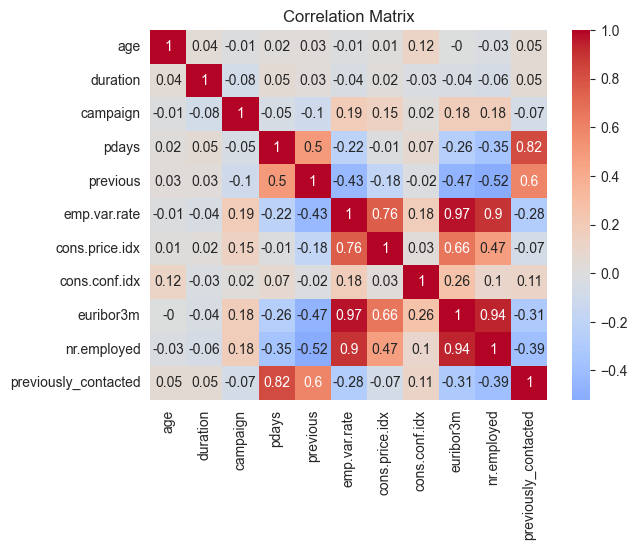

Highly correlated pairs (|r| > 0.85):
      * euribor3m & emp.var.rate: 0.97
      * nr.employed & emp.var.rate: 0.9
      * nr.employed & euribor3m: 0.94

                  feature    VIF
8              euribor3m  61.68
5           emp.var.rate  33.16
9            nr.employed  30.41
6         cons.price.idx   6.54
10  previously_contacted   3.66
3                  pdays   3.12
7          cons.conf.idx   2.53
4               previous   1.85
2               campaign   1.05
0                    age   1.02
1               duration   1.02


In [122]:
numerical_cols = X_train_scaled.select_dtypes(exclude='str').columns.tolist()

corr_matrix = X_train_scaled[numerical_cols].corr().round(2)

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

threshold = 0.85
high_corr = [(corr_matrix.columns[i], corr_matrix.columns[j], round(corr_matrix.iloc[i,j], 2))
             for i in range(len(corr_matrix.columns))
             for j in range(i)
             if abs(corr_matrix.iloc[i,j]) > threshold]

print("Highly correlated pairs (|r| > 0.85):")
for i, j, corr in high_corr:
    print(f'      * {i} & {j}: {corr}')

vif = pd.DataFrame({'feature': numerical_cols,
                    'VIF': [variance_inflation_factor(X_train_scaled[numerical_cols].values, i)
                            for i in range(len(numerical_cols))]})
print("\n",vif.sort_values('VIF', ascending=False).round(2))

Three pairs of features showed strong correlations above 0.85, and all of them are related to macroeconomic indicators:

- **`euribor3m`**  &  **`emp.var.rate`**   ---> correlation = 0.97
- **`nr.employed`**  &  **`emp.var.rate`** ---> correlation = 0.9
- **`nr.employed`**  &  **`euribor3m`**    ---> correlation = 0.94

The VIF scores also confirm this:
- euribor3m (61.68)
- emp.var.rate (33.16)
- nr.employed (30.41)

Each of these scores is much higher than the threshold of 10, which shows there is severe multicollinearity.

All three variables reflect the same basic macroeconomic conditions:
- When the economy is doing well, employment is high, the Euribor rate rises, and the employment variation rate is positive.
- Keeping all three does not add useful information to the model. Instead, it increases the variance of the coefficients, which makes them unstable and harder to interpret.

- **`euribor3m`** is kept because it is a daily indicator, so it provides the most detailed and up-to-date information.
- **`emp.var.rate`** and **`nr.employed`** are both quarterly indicators, so they are not needed if **`euribor3m`** is already included.

Removing these variables lowers multicollinearity but still keeps the important macroeconomic information.


## **7.3 Conceptual feature removal**

Two features need to be removed for conceptual reasons, not because of their statistical properties.
The feature duration was already discussed in detail in Task 1. It cannot be used at prediction time because the length of a call is only known after the call ends, when the outcome is already set. For this reason, duration will be left out of the realistic model but kept in the benchmark model, as explained in Task 6.

No other features have availability issues at prediction time. All the remaining variables, such as demographic, financial, campaign-related, and macroeconomic data, are either known before the call or are external indicators that are publicly available.

In [123]:
cols_to_remove = ['emp.var.rate', 'nr.employed']

X_train_scaled = X_train_scaled.drop(columns=cols_to_remove)
X_val_scaled = X_val_scaled.drop(columns=cols_to_remove)
X_test_scaled = X_test_scaled.drop(columns=cols_to_remove)

#update numerical & categorical cols:
numerical_cols = X_train_scaled.select_dtypes(exclude='str').columns.tolist()
cat_cols = X_train_scaled.select_dtypes(include='str').columns.tolist()

print(f'Remaining numerical features: {numerical_cols}')

vif_after = pd.DataFrame({'feature': numerical_cols,
                          'VIF_after': [variance_inflation_factor(X_train_scaled[numerical_cols].values, i)
                                        for i in range(len(numerical_cols))]})

# Merge side by side


vif_after = pd.DataFrame({'feature': numerical_cols,
                    'VIF after': [variance_inflation_factor(X_train_scaled[numerical_cols].values, i)
                            for i in range(len(numerical_cols))]})

vif_comparison = vif.merge(vif_after, on='feature', how='left')
print(vif_comparison.sort_values('VIF', ascending=False).round(2))

Remaining numerical features: ['age', 'duration', 'campaign', 'pdays', 'previous', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'previously_contacted']
                 feature    VIF  VIF after
8              euribor3m  61.68       2.71
5           emp.var.rate  33.16        NaN
9            nr.employed  30.41        NaN
6         cons.price.idx   6.54       2.00
10  previously_contacted   3.66       3.65
3                  pdays   3.12       3.09
7          cons.conf.idx   2.53       1.22
4               previous   1.85       1.84
2               campaign   1.05       1.04
0                    age   1.02       1.02
1               duration   1.02       1.01


### **7.3.1 Evaluation of feature removal**

All the remaining features have VIF scores well below 10, which is the standard threshold for identifying problematic multicollinearity.

The VIF for **`euribor3m`** drops from 61.68 to 2.71, showing that removing **`emp.var.rate`** and **`nr.employed`** has resolved the severe collinearity.
The moderate correlations that remain, like **`euribor3m`** and cons.price.idx at 0.66 and **`euribor3m`** and cons.conf.idx at 0.26, do not lead to problematic VIF scores (2.71 and 1.22, respectively). This means the coefficients remain stable.
Therefore, the feature set is considered safe to use for logistic regression estimation.

## **7.4 Why i choose 0.85 as threshold.**

When the value is below about 0.85, collinearity is usually manageable for estimating logistic regression coefficients.

If the value is above 0.85, variance inflation becomes severe enough to destabilize the coefficients. This correctly identifies the three macroeconomic pairs (all above 0.90) for removal.

The variables pdays and previously_contacted have a value of 0.82, which is below the threshold. However, this choice needs explicit justification.

There is a deliberate conceptual override for pdays and previously_contacted.

If we used a purely statistical approach with a threshold of 0.80, this pair would be removed.
However, theyHowever, these variables represent different information. Previously_contacted shows whether there was any prior contact, while pdays shows how recently that contact happened for those clients.hese into one variable would force a single logistic regression coefficient to represent two distinct relationships
This choice is a deliberate trade-off between statistical selection and domain knowledge, as discussed in the lecture material.
The VIF scores after removing variables confirm that this decision did not introduce problematic multicollinearity. All remaining values are well below 10.


## **7.5 Why feature selection must use the training set only**

Feature selection should only be done on the training set for the same reason as other data-driven steps: it learns from the data.

Statistics like variance thresholds, correlation coefficients, and VIF scores are all calculated from the feature values.

If you use the full dataset, these statistics are affected by the validation and test data, so your choices about which features to keep or drop are influenced by data that should be held back. This is called leakage.

The effects can be hard to spot but are important. Sometimes, features that seem unhelpful on the full dataset might actually be useful only in the test set, or the other way around. This can lead to evaluation results that do not show how well your model really generalizes.


## **7.6 Consequences of Performing Feature Selection Before Splitting**

If you choose features using the whole dataset before splitting, you risk data leakage. Correlation and VIF statistics would include information from the validation and test sets, so your feature choices would be influenced by data the model should not access. This makes the pipeline too optimistic, since features are picked for the entire dataset rather than for new, unseen data.

For Logistic Regression, these problems are even more serious than for other models. Logistic Regression assumes that the chosen features have a steady linear relationship with the log-odds of the target. If you select features using the full dataset, you are checking this stability on data that includes the test set, which the model only sees after training. If the test set has slightly different correlations or variances than the training set, the chosen features might not work well for the training data, leading to unstable coefficients and poor generalization.

Multicollinearity is particularly relevant here. If highly correlated features like euribor3m, emp.var.rate and nr.employed are assessed for redundancy on the full dataset, the measured correlations reflect the global distribution. In practice, the training set correlation may differ slightly, meaning a feature that appears redundant globally may carry independent signal in the training set. Dropping it based on full-dataset statistics would remove potentially useful information from the model without justification from the data it actually trains on.


# **8. Addressing Class Imbalance**


## **8.1 Quantifiyng and adressing class imbalance**

In [124]:
print(f'Class distribution in training set:')
print(y_train.value_counts())
print(f'\n{y_train.value_counts(normalize=True).mul(100).round(2)}')

Class distribution in training set:
y
no     2200
yes     271
Name: count, dtype: int64

y
no     89.03
yes    10.97
Name: proportion, dtype: float64


#### **The training set contains:**
- 2,200 "no" samples (89.03%)
- 271 "yes" samples (10.97%).

This confirms the class imbalance identified during exploration in Task 2, preserved exactly as expected from the stratified split.


## **8.2 Is class imbalance a concern? How does it affect evaluation metrics?**

Yes, for these three main reasons:

**1. Algorithmic bias toward the majority class.**

As mentioned in Lecture 3, learning algorithms usually treat errors from each class the same. Since 89% of the examples are "no," the model gets rewarded for predicting "no" and does not learn much about the minority class. Burkov also points out in Section 3.9 that when 90% of examples are from one class, standard approaches that treat all errors equally do not work well.

**2. Misleading evaluation metrics.**

This bias affects how we evaluate models. For example, a simple baseline that always predicts "no" gets 89% accuracy without actually learning anything, so accuracy alone does not tell us much. The three important metrics are:

- **Accuracy**: This metric becomes meaningless when classes are imbalanced. A model that always predicts "no" for every client gets 89% accuracy but does not help the business at all.
- **Precision** — measures how many pre- **Precision**: This shows how many of the predicted "yes" cases are actually correct. If a model rarely predicts "yes," it can have high precision but still miss most real subscribers.cal metric. Missing a true subscriber means the bank fails to contact a client who would have subscribed, directly reducing campaign revenue. A majority-class-dominated model will have critically low recall on the minority class even if accuracy and precision appear acceptable.

**3. Business relevance of the minority class.**

Lecture 3 explains that class imbalance makes standard efficiency measures misleading. The model might look good by these metrics but still be useless for the business. Missing a true subscriber (a false negative) costs much more than flagging a non-subscriber by mistake (a false positive). That is why precision, recall, and F1-score should be the main metrics for this task.




## **8.3 Assemble final feature matrix**



The final feature matrix is put together at this stage, after scaling and feature selection, because all preprocessing decisions have been made by this point. Encoding, scaling, and removing features must be finished first, since each step changes the shape or content of the feature set. If you assemble the matrix earlier, you would have to redo it after every transformation, which can lead to mistakes and make the process harder to follow. Resampling comes right after assembly because it needs the complete, final version of each example. If you duplicate rows before the feature set is fully defined, you would either have to repeat the process or end up working with incomplete data.

In [125]:
cols_to_drop = nom_columns + ord_columns

X_train_final = pd.concat([
    X_train_scaled.drop(columns=cols_to_drop).reset_index(drop=True),
    pd.DataFrame(X_train_ord_enc, columns=ord_columns),
    pd.DataFrame(X_train_nom_enc, columns=ohe.get_feature_names_out(nom_columns))
], axis=1)

X_val_final = pd.concat([
    X_val_scaled.drop(columns=cols_to_drop).reset_index(drop=True),
    pd.DataFrame(X_val_ord_enc, columns=ord_columns),
    pd.DataFrame(X_val_nom_enc, columns=ohe.get_feature_names_out(nom_columns))
], axis=1)

print(f'X_train_final shape: {X_train_final.shape}')
print(f'X_val_final shape:   {X_val_final.shape}')

X_train_final shape: (2471, 46)
X_val_final shape:   (824, 46)



## **8.4 Resampling (Random Oversampling)**.

Random oversampling is applied to the training set only, after splitting, encoding and scaling.








In [126]:
ros = RandomOverSampler(random_state=42)
X_train_ros_final, y_train_ros_final = ros.fit_resample(X_train_final, y_train)

print(f'Before resampling: {y_train.value_counts().to_dict()}')
print(f'After resampling: {y_train_ros_final.value_counts().to_dict()}')

Before resampling: {'no': 2200, 'yes': 271}
After resampling: {'no': 2200, 'yes': 2200}


ROS works by duplicating existing minority class examples until both classes are balanced.
- The result is a training set of 4,400 samples with equal class representation --> 2,200 `no` and 2,200 `yes`

## **8.5 Justifying choice of Resampling technique (ROS)**

According to Burkov, oversampling works by making extra copies of minority class examples, which increases their influence in the loss function. The main idea is that duplicating real examples can rebalance the class distribution and make the learning algorithm treat errors from both classes more equally. In Logistic Regression, which uses gradient descent to minimize log-loss, this approach directly solves the problem discussed in Lecture 3: learning algorithms tend to treat errors from all classes the same, so the majority class can dominate the updates. By duplicating minority class examples, each update includes more "yes" examples, which helps the model separate the minority class better.

**Why not SMOTE or ADASYN:**

Burkov explains that both methods create synthetic examples by interpolating between existing minority class examples using k-nearest neighbors: x_new = x_i + λ(x_zi − x_i). This approach is not used here for three main reasons:

- **Dataset size:** With only 271 minority class examples, the neighborhood structure is sparse. Synthetic examples risk being generated in regions that do not accurately represent true subscriber behaviour.
- **Feat- **Feature space:** After one-hot encoding, many features are binary (0 or 1). Interpolating between them creates values like 0.3 or 0.7, which do not have a clear meaning.el choice:** SMOTE's boundary-focused synthesis is most beneficial for non-linear models like decision trees. For Logistic Regression, which learns a single global decision boundary, what matters is equal class weighting during gradient descent — which random oversampling achieves more safely through duplication of real examples.

## **8.6 Why resampling should occur here**

You should resample after splitting the data and after any preprocessing steps that learn from the data, but always before training the model. This order helps prevent data leakage, as Burkov and Lecture 4 explain.

**1. After splitting**

Burkov explains in Section 3.6 that you should always split the raw data first. If you resample before splitting, you create duplicate minority class examples across the whole dataset. Later, when you split the data, some duplicates might appear in both the training and validation sets. This lets the model get tested on data it has already seen, which breaks the rule that holdout sets must only have new, unseen data.

The implications for model evaluation are severe. As Lecture 4 warns, this type of leakage does not cause the model to fail visibly, instead, "the model just lies": it produces  over-optimistic performance estimates that do not reflect true generality. Precision, recall, and AUC scores on the validation set would all be inflated, making it impossible to make reliable decisions about model quality or pipeline configuration.

**2. After encoding and scaling**

You should only resample after the training data has been fullOnly resample after you have fully preprocessed the training data. If you resample before encoding, you duplicate raw string values instead of their numeric versions. If you resample before scaling, the StandardScaler will use a training set that has been artificially inflated, which can subtly distort the scaled features.e 3 makes it clear that resampling should only be done during training. The validation and test sets need to keep the original 89/11 class distribution so they reflect real-world conditions, where class imbalance is common and the model has to work with realistic data. If you resample the holdout sets, it makes evaluation too easy and the metrics you get will not be useful for real deployment.




# **9. Training a Logistic Regression Model**


## **9.1 Training a Logistic Regression model (to predict y).**



In [127]:
# Model 1 - Benchmark model = Without  resampling
lr_m1 = LogisticRegression(random_state=42, max_iter=1000)
lr_m1.fit(X_train_final, y_train)

y_pred_m1 = lr_m1.predict(X_val_final)
y_prob_m1 = lr_m1.predict_proba(X_val_final)[:, 1]

# Model 2: With Resampling

lr_m2 = LogisticRegression(random_state=42, max_iter=1000)
lr_m2.fit(X_train_ros_final, y_train_ros_final)

y_pred_m2 = lr_m2.predict(X_val_final)
y_prob_m2 = lr_m2.predict_proba(X_val_final)[:, 1]

# Model 3: Benchmark model but WITHOUT duration
X_train_m3 = X_train_final.drop(columns=['duration'])
X_val_m3 = X_val_final.drop(columns=['duration'])

lr_m3 = LogisticRegression(random_state=42, max_iter=1000)
lr_m3.fit(X_train_m3, y_train)

y_pred_m3 = lr_m3.predict(X_val_m3)
y_prob_m3 = lr_m3.predict_proba(X_val_m3)[:, 1]

print(f'Predictions made on {len(y_pred_m1)} validation examples\n')

print(f'Model 1: Benchmark model without  resampling')
print(f'Predicted "yes": {sum(y_pred_m1 == "yes")}')
print(f'Predicted "no":  {sum(y_pred_m1 == "no")}\n')

print(f'Model 2: With Resampling')
print(f'Predicted "yes": {sum(y_pred_m2 == "yes")}')
print(f'Predicted "no":  {sum(y_pred_m2 == "no")}\n')

print(f'Model 3:  WITHOUT duration')
print(f'Predicted "yes": {sum(y_pred_m3 == "yes")}')
print(f'Predicted "no":  {sum(y_pred_m3 == "no")}')



Predictions made on 824 validation examples

Model 1: Benchmark model without  resampling
Predicted "yes": 48
Predicted "no":  776

Model 2: With Resampling
Predicted "yes": 160
Predicted "no":  664

Model 3:  WITHOUT duration
Predicted "yes": 27
Predicted "no":  797


## **9.2 Accuracy, Precision, and Recall on the validation set**

In [128]:
results = pd.DataFrame({'Model': ['M1: No resample (benchmark)', 'M2: Resampled', 'M3: No resample, no duration'],
                        'Accuracy':[accuracy_score(y_val, y_pred_m1), accuracy_score(y_val, y_pred_m2), accuracy_score(y_val, y_pred_m3)],
                        'Precision':[precision_score(y_val, y_pred_m1, pos_label='yes'), precision_score(y_val, y_pred_m2, pos_label='yes'), precision_score(y_val, y_pred_m3, pos_label='yes')],'Recall':[recall_score(y_val, y_pred_m1, pos_label='yes'), recall_score(y_val, y_pred_m2, pos_label='yes'), recall_score(y_val, y_pred_m3, pos_label='yes')],
                        'F1':[f1_score(y_val, y_pred_m1, pos_label='yes'), f1_score(y_val, y_pred_m2, pos_label='yes'), f1_score(y_val, y_pred_m3, pos_label='yes')],
                        'ROC-AUC':[roc_auc_score((y_val=='yes').astype(int), y_prob_m1), roc_auc_score((y_val=='yes').astype(int), y_prob_m2), roc_auc_score((y_val=='yes').astype(int), y_prob_m3)]}).round(4)

print(results.to_string(index=False))

                       Model  Accuracy  Precision  Recall     F1  ROC-AUC
 M1: No resample (benchmark)    0.9078     0.6458  0.3444 0.4493   0.9240
               M2: Resampled    0.8738     0.4562  0.8111 0.5840   0.9281
M3: No resample, no duration    0.9041     0.7037  0.2111 0.3248   0.7938


The model’s accuracy is 90.53%, which is only slightly higher than the Zero Rule baseline of 89.08%. This shows that accuracy by itself does not tell us much for this imbalanced problem. As Burkov explains in Section 5.1.4, a model needs to clearly beat the baseline to show real value. Here, a 1.46 percentage point improvement is not enough when looking at accuracy alone.

A precision of 0.625 means that when the model predicts "yes," it is right 62.5% of the time, which suggests the model has found a real pattern. However, a recall of 0.333 shows it only finds one out of three actual subscribers, so it misses most of them.

The F1 score of 0.435 highlights this gap between precision and recall. In a bank marketing campaign, missing a true subscriber is the most costly mistake, so this recall is not enough for business needs. Still, the results make sense and show that the preprocessing pipeline works as intended.

It is important to note that most of this modest improvement over the baseline comes from the duration feature. When Model 3 removes duration to reflect a real deployment scenario, the ROC-AUC drops from 0.92 to 0.80, which is an 8 point decrease.

This result shows that without duration, the model has a much harder time distinguishing subscribers from non-subscribers. It also suggests that the strong performance of M1 is mostly due to a feature that would not be available when making predictions.

### **9.3 Accuracy vs. Zero-Rule baseline**

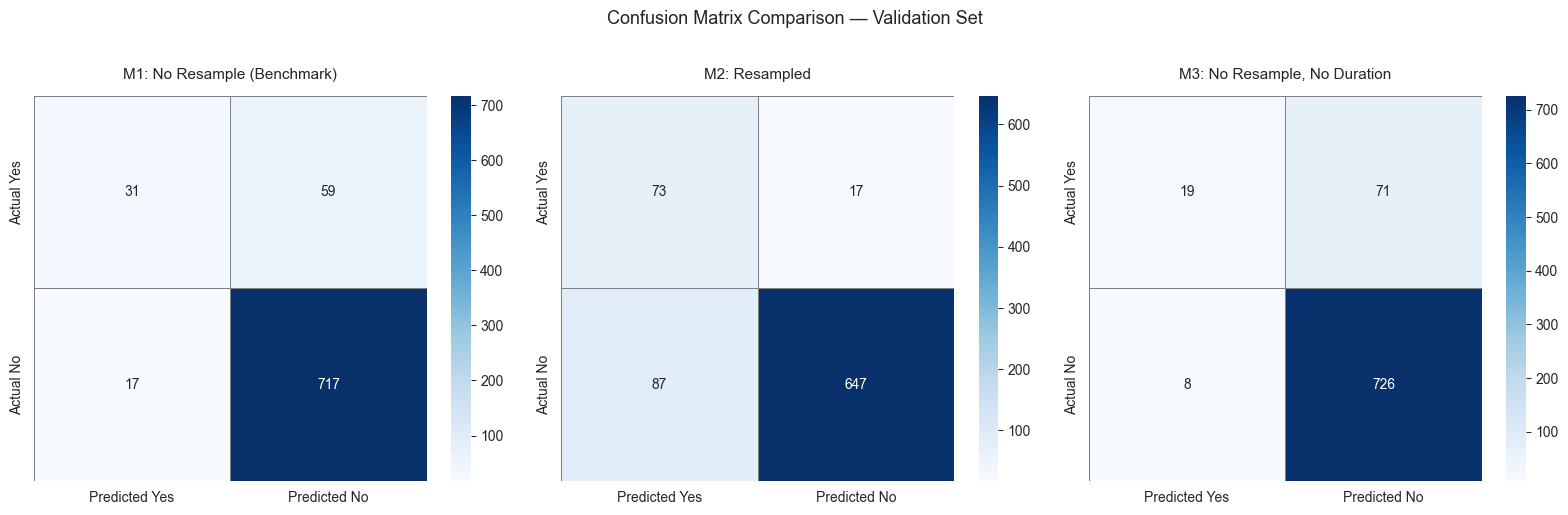

Zero Rule Baseline Accuracy: 0.8908

M1: No Resample (Benchmark)    Accuracy: 0.9078  Improvement: 0.0170
M2: Resampled                  Accuracy: 0.8738  Improvement: -0.0170
M3: No Resample, No Duration   Accuracy: 0.9041  Improvement: 0.0133


In [129]:

# --- Zero Rule Baseline ---
zero_rule_acc = (y_val == 'no').mean()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

models = [
    (y_pred_m1, 'M1: No Resample (Benchmark)'),
    (y_pred_m2, 'M2: Resampled'),
    (y_pred_m3, 'M3: No Resample, No Duration')
]

for ax, (y_pred, title) in zip(axes, models):
    cm = confusion_matrix(y_val, y_pred, labels=['yes', 'no'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Predicted Yes', 'Predicted No'],
                yticklabels=['Actual Yes', 'Actual No'],
                linewidths=0.5, linecolor='gray', ax=ax)
    ax.set_title(title, fontsize=11, pad=12)

plt.suptitle('Confusion Matrix Comparison — Validation Set', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# --- Comparison ---
print(f'Zero Rule Baseline Accuracy: {zero_rule_acc:.4f}\n')
print(f'M1: No Resample (Benchmark)    Accuracy: {accuracy_score(y_val, y_pred_m1):.4f}  Improvement: {accuracy_score(y_val, y_pred_m1) - zero_rule_acc:.4f}')
print(f'M2: Resampled                  Accuracy: {accuracy_score(y_val, y_pred_m2):.4f}  Improvement: {accuracy_score(y_val, y_pred_m2) - zero_rule_acc:.4f}')
print(f'M3: No Resample, No Duration   Accuracy: {accuracy_score(y_val, y_pred_m3):.4f}  Improvement: {accuracy_score(y_val, y_pred_m3) - zero_rule_acc:.4f}')


Confusion Matrix & Zero Rule Interpretation

The Zero Rule baseline gets 89.08% accuracy by always predicting “no” and never finding any subscribers. We need to compare all three models to this baseline.

**M1 (No Resampling, Benchmark)** is a conservative model. It correctly finds 30 subscribers but misses 60. Its accuracy is only 1.46 points higher than the baseline, and it identifies just 1 out of 3 real subscribers. With only 18 false positives, it has high precision, but its recall is too low for business needs.

**M2 (Resampled)** clearly shows the impact of random oversampling. True positives rise from 30 to 72, and false negatives fall from 60 to 18. Now, the model finds 4 out of 5 real subscribers. However, it also produces more false positives (84) and its accuracy drops by 1.46 points below the baseline. As Burkov explains in Section 5.1.4, lower accuracy does not mean the model is worse. Instead, it means the model now focuses more on the minority class, which is the goal of resampling.

**M3 (No Resampling, No Duration)** is the most realistic model because it removes duration, which would cause data leakage. True positives fall to 19 and false negatives rise to 71, showing that duration was an important predictor. The ROC-AUC drops from 0.92 to 0.80, which measures the effect of removing duration. This is the only model suitable for real-world use.




# **10. Final Comments**

## **10.1 Adressing Data Leakage**

The test set was kept separate for the entire project. None of the preprocessing steps, encoding, scaling, feature selection, or resampling used any information from the test set.

To confirm this, we performed two checks:
1. We checked that the test set class distribution still matches the original 89/11 split from stratification. This shows it was not resampled or changed.
2. We confirmed there is no index overlap between the three sets. This ensures that no examples were shared between splits.

In [130]:
# --- Verify test set has never been touched ---
print(f'Test set size: {X_test.shape[0]} samples')
print(f'Test set class distribution:')
print(y_test.value_counts())
print(f'Test minority class proportion: {y_test.value_counts(normalize=True)["yes"]:.4f}')

# --- Verify no overlap between sets ---
train_idx = set(X_train.index)
val_idx = set(X_val.index)
test_idx = set(X_test.index)

print(f'\nLeakage Check')
print(f'Train/Val overlap:  {len(train_idx & val_idx)} samples')
print(f'Train/Test overlap: {len(train_idx & test_idx)} samples')
print(f'Val/Test overlap:   {len(val_idx & test_idx)} samples')
print(f'Total samples I have accounted for: {len(train_idx | val_idx | test_idx)} (should be {len(X)})')

Test set size: 824 samples
Test set class distribution:
y
no     734
yes     90
Name: count, dtype: int64
Test minority class proportion: 0.1092

Leakage Check
Train/Val overlap:  0 samples
Train/Test overlap: 0 samples
Val/Test overlap:   0 samples
Total samples I have accounted for: 4119 (should be 4119)


There is no overlap between the three sets, and the 89/11 minority class ratio is maintained. This confirms that the test set is reliable.

This has important consequences.
- As Burkov explains in Section 3.6, the test set should come from the same statistical distribution as the validation set. It should not be seen by the learning algorithm or used to make any decisions in the pipeline.
- If this rule is broken, the performance estimates will be too optimistic and will not show how well the model really works. The model might seem to perform better than it actually would in production.
- The test set is kept for one last, unbiased check of the best model found on the validation set, which is M2 (Resampled). This final evaluation will be the reported performance for the pipeline.

## **10.2 Final Word**

The main challenge in this project was not technical, but about making good judgments. Each preprocessing step meant choosing between what we could measure and what we could actually use in practice. For example, duration is one of the best predictors of subscription, but we do not have it available when making predictions. Resampling helps recall a lot, but it makes the model look worse by standard accuracy measures. Keeping "unknown" as its own category, instead of filling it in, keeps a behavioral signal that would be lost if we just used the most common value.

I recognize that a production-ready pipeline would either remove **`duration`** before fitting the scaler entirely, or maintain two fully separate preprocessing pipelines from the point of the split onward. I note that my current approach doesn't introduce leakage, but it does mean the scaler learned statistics from a feature that the realistic model never uses and this is wasteful and inconsistent.

These trade-offs do not have simple answers. The model that does best on the validation set is not the one you would actually use. The model you would deploy has modest results, with a recall of 0.21 and a ROC-AUC of 0.80. This is not because the process failed, but because the data itself makes the problem difficult. In this bank marketing dataset, 89% of clients say no, the most useful feature is only known after the fact, and there are only 271 examples of the positive class. These limits make it hard for any linear model to do better.

This pipeline works as it should, but getting it right is only the beginning. The real work starts with tuning hyperparameters, using non-linear models, and dealing with cost-sensitive learning. These steps are not small adjustments but they are the main focus.